In [1]:
import geopandas as gpd
import libpysal
from esda.moran import Moran_Local
import numpy as np
import pandas as pd
from osgeo import gdal

c:\Users\admin\miniforge3\envs\pomelo\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Open predicted raster
pred_ds = gdal.Open(r'E:\fake-pomelo\outputs\sample 18\vnm_predicted_target_img_adjusted.tiff')
pred_band = pred_ds.GetRasterBand(1)
pred_raster = pred_band.ReadAsArray()

# Open fine ID raster
fine_ds = gdal.Open(r'E:\fake-pomelo\pomelo_input_data\VNM\vnm_humdata_regions.tif')
fine_band = fine_ds.GetRasterBand(1)
fine_id_raster = fine_band.ReadAsArray()

gdf = gpd.read_file(r'E:\fake-pomelo\pomelo_input_data\VNM_Sample_18\Sample_18.shp')

In [5]:
gdf = gdf.drop(columns=['pred_pop', 'residual','pop_dens_1','pop_built_', 'residual_p', 'dens_p_val',
       'builtDensP', 'pop_p',])

In [6]:
mask = []
pred_pop = []
count = 0
for id in gdf['SID']:
    count += 1
    print(count)
    mask = fine_id_raster == id
    pred_pop.append(np.nansum(pred_raster[mask]))

1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
277


In [7]:
gdf['pred_pop'] = pred_pop
gdf["residual"] = gdf['pred_pop'] - gdf['Total_popu']
gdf[['Total_popu', 'pred_pop', "residual"]]

,Total_popu,pred_pop,residual
0,9574.0,18108.105469,8534.105469
1,16538.0,15062.628906,-1475.371094
2,11625.0,11087.709961,-537.290039
3,6815.0,5394.737305,-1420.262695
4,9302.0,7076.452148,-2225.547852
...,...,...,...
11156,3295.0,3944.794189,649.794189
11157,3761.0,4163.020508,402.020508
11158,11979.0,8673.269531,-3305.730469
11159,3761.0,4626.519043,865.519043


In [12]:
from esda.moran import Moran
results = []
w = libpysal.weights.KNN.from_dataframe(gdf, k=3)
variables = ['pred_pop', 'residual', 'Total_popu']

for var in variables:
    values = gdf[var].values
    
    mi = Moran(values, w)
    
    results.append({
        'variable': var,
        'moran_I': mi.I,
        'p_value': mi.p_sim,
        'z_score': mi.z_sim
    })

# convert sang DataFrame
results_df = pd.DataFrame(results)

# lưu CSV
output_path = r'E:\fake-pomelo\pomelo_input_data\VNM_Sample_18\morans_results.csv'
results_df.to_csv(output_path, index=False)

In [14]:
gdf.to_file(r'E:\fake-pomelo\pomelo_input_data\VNM_Sample_18\Sample_18.shp', driver='ESRI Shapefile')

In [21]:
gdf['pred_dens'] = gdf['pred_pop'] / gdf['building_c']  
gdf['pop_dens'] = gdf['Total_popu'] / gdf['building_c']  
gdf['residDens'] = gdf['residual'] / gdf['building_c'] 

In [24]:
gdf['pred_dens']

0        2.117659
1        1.242484
2        1.327869
3        1.231113
4        1.282896
           ...   
11156    1.005812
11157    0.970627
11158    0.768634
11159    0.850151
11160    0.995385
Name: pred_dens, Length: 11161, dtype: float64

In [30]:
gdf['residDens'] = abs(gdf['residDens'])

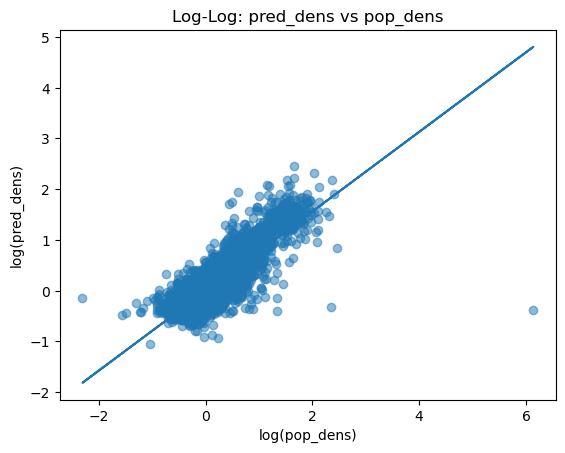

c:\Users\admin\miniforge3\envs\pomelo\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


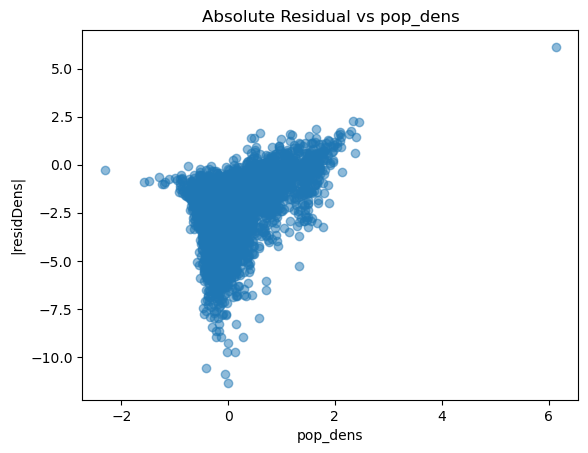

In [38]:
import numpy as np
import matplotlib.pyplot as plt

# Giả sử dataframe là gdf hoặc df
df = gdf.copy()

# Loại bỏ giá trị <= 0 để log không bị lỗi
df_log = df[(df['pop_dens'] > 0) & (df['pred_dens'] > 0)].copy()

# ===== Plot 1: log-log =====
plt.figure()
plt.scatter(
    np.log(df_log['pop_dens']),
    np.log(df_log['pred_dens']),
    alpha=0.5
)
plt.xlabel('log(pop_dens)')
plt.ylabel('log(pred_dens)')
plt.title('Log-Log: pred_dens vs pop_dens')

# fit regression line (optional)
m, b = np.polyfit(
    np.log(df_log['pop_dens']),
    np.log(df_log['pred_dens']),
    1
)
plt.plot(
    np.log(df_log['pop_dens']),
    m * np.log(df_log['pop_dens']) + b
)

plt.show()


# ===== Plot 2: abs residual =====
plt.figure()
plt.scatter(
    np.log(df_log['pop_dens']),
    np.log(np.abs(df_log['residDens'])),
    alpha=0.5
)
plt.xlabel('pop_dens')
plt.ylabel('|residDens|')
plt.title('Absolute Residual vs pop_dens')

# fit regression line (optional)
m, b = np.polyfit(
    np.log(df_log['pop_dens']),
    np.log(np.abs(df_log['residDens'])),
    1
)
plt.plot(
    np.log(df_log['pop_dens']),
    m * np.log(df_log['pop_dens']) + b
)

plt.show()